<a href="https://colab.research.google.com/github/Lu2077/PythonAI/blob/main/GenImages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Contenido del directorio después de la extracción:
['.config', '10.jpg', '4.jpg', '7.jpg', '15.jpg', '14.jpg', '23.jpg', '17.zip', '19.png', '11.jpg', '18.jpg', '11.png', '22.jpg', '20.png', '9.jpg', '16.jpg', '17.jpg', '12.jpg', '13.jpg', '25.jpg', '21.jpg', 'sample_data']
Ruta de la imagen: /content/19.png
Archivo existe: True


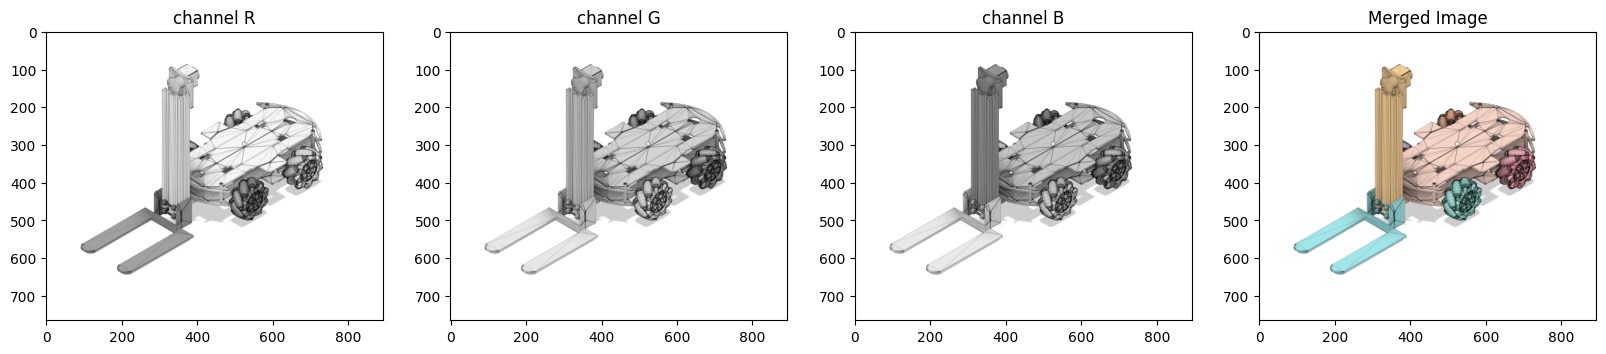

In [ ]:
#https://www.dropbox.com/scl/fi/ar28cja6araihjgcmz7nz/17.zip?rlkey=s08bzm0ndgouuck01zpj9yh8u&st=9dvbdaej&dl=0
# Transformación de Colores
#-----------------------------------------------------------------------------#
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Image

def download_and_unzip(url, save_path):
    print("Downloading and extracting assets...", end="")

    # Descargar archivo ZIP
    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            # Listar el contenido del archivo ZIP
            print("Contenido del archivo ZIP antes de la extracción:")
            for name in z.namelist():
                print(name)

            # Extraer contenido del archivo ZIP en el directorio actual
            z.extractall(os.getcwd())
        print("Done")
    except Exception as e:
        print("\nInvalid file.", e)

# URL del archivo ZIP en Dropbox
URL = r"https://www.dropbox.com/scl/fi/5v7bvjzwwqxux6xphpgvn/17.zip?rlkey=rqqz6itdq03i8ey5ubm9bthti&st=tj3q2pke&dl=1"
asset_zip_path = os.path.join(os.getcwd(), "17.zip")

# Descargar y extraer el archivo ZIP si no existe
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Listar archivos en el directorio actual para verificar la existencia del archivo de imagen
print("Contenido del directorio después de la extracción:")
print(os.listdir(os.getcwd()))

# Verificar la ruta de la imagen
image_path = os.path.join(os.getcwd(), "19.png")
print(f"Ruta de la imagen: {image_path}")
print(f"Archivo existe: {os.path.exists(image_path)}")

# Leer la imagen
img_5_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
if img_5_bgr is None:
    raise ValueError("La imagen no se pudo cargar. Verifica la ruta del archivo y asegúrate de que el archivo existe.")

# Separar los canales de color
b, g, r = cv2.split(img_5_bgr)

# Visualizar los canales y la imagen fusionada
plt.figure(figsize=[20, 5])
plt.subplot(141); plt.imshow(r, cmap="gray"); plt.title("channel R")
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title("channel G")
plt.subplot(143); plt.imshow(b, cmap="gray"); plt.title("channel B")

imgMerged = cv2.merge([b, g, r])
plt.subplot(144)
plt.imshow(imgMerged[:, :, ::-1])
plt.title("Merged Image")
plt.show()

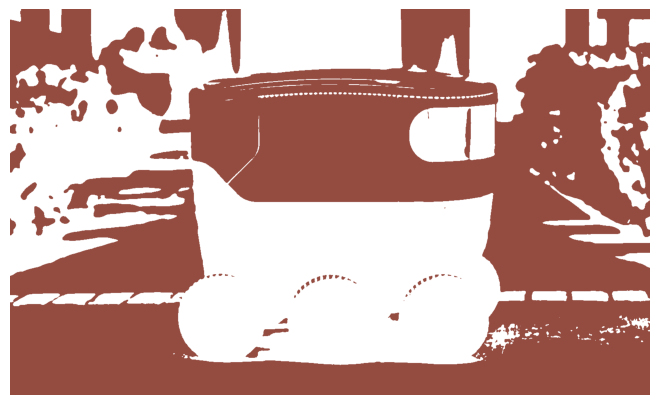

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen en escala de grises y redimensionarla
img_gray = cv2.imread('22.jpg', cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(img_gray, (img_gray.shape[1]*2, img_gray.shape[0]*2))  # Duplicar el tamaño

# Invertir el contraste de la imagen
img_invertida = cv2.bitwise_not(img_gray)

# Aplicar filtro Gaussiano
blurred = cv2.GaussianBlur(img_invertida, (5, 5), 0)

# Aplicar umbral para segmentación básica
_, segmented = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# Crear una imagen de color para el fondo
background_color = (64, 75, 148)  # Color de fondo personalizado
colored_background = np.zeros((img_gray.shape[0], img_gray.shape[1], 3), dtype=np.uint8)
colored_background[:] = background_color

# Crear una imagen en blanco para colorear los segmentos
color_segmentos = np.zeros_like(colored_background)

# Definir el color deseado para los segmentos en formato BGR (blanco)
color = [255, 255, 255]  # Segmentos blancos

# Aplicar el color a los segmentos detectados
color_segmentos[segmented != 0] = color

# Combinar la imagen original con los segmentos coloreados
resultado = cv2.addWeighted(colored_background, 1, color_segmentos, 1, 0)

# Mostrar la imagen resultante sin títulos ni ejes y eliminar el marco blanco
fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
ax.axis('off')  # Desactivar los ejes
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Eliminar el marco blanco
plt.show()

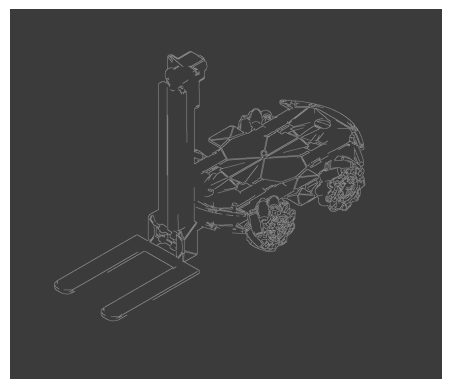

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen en escala de grises y redimensionarla
img_gray = cv2.imread('19.png', cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(img_gray, (img_gray.shape[1]*2, img_gray.shape[0]*2))  # Duplicar el tamaño

# Aplicar filtro Gaussiano
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplicar algoritmo Canny para detectar bordes
edges = cv2.Canny(blurred, 100, 200)

# Crear una imagen de color para el fondo
background_color = (59, 59, 59)  # Color de fondo personalizado
colored_background = np.zeros((img_gray.shape[0], img_gray.shape[1], 3), dtype=np.uint8)
colored_background[:] = background_color

# Crear una imagen en blanco para colorear los bordes
color_bordes = np.zeros_like(colored_background)

# Definir el color deseado para los bordes en formato BGR (blanco)
color = [255, 255, 255]  # Bordes blancos

# Aplicar el color a los bordes detectados
color_bordes[edges != 0] = color

# Combinar la imagen original con los bordes coloreados
resultado = cv2.addWeighted(colored_background, 1, color_bordes, 1, 0)

# Mostrar la imagen resultante sin títulos ni ejes
plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
plt.axis('off')  # Desactivar los ejes
plt.show()

Debian-logo.png
images.png
linux-2025130_1280.webp
maxresdefault.jpg
Raspberry_Pi_OS_Logo.png
Raspberry_Pi-Logo.wine.png
ros_logo.png
tux-linux-foxyriot-logo-wallpaper.jpg
cpp-logo.png
d831ab6f16f82c542868bbd8b708c828.jpg
debian-logo.jpg
Done
Contenido del directorio después de la extracción:
['.config', '10.jpg', '4.jpg', '7.jpg', 'debian-logo.jpg', '15.jpg', '14.jpg', '23.jpg', 'ros_logo.png', '17.zip', 'logos.zip', '19.png', '11.jpg', '18.jpg', '11.png', '22.jpg', 'linux-2025130_1280.webp', '20.png', '9.jpg', 'linux1.png', 'images.png', '16.jpg', 'ubuntulogo1.jpg', 'logoduino.png', 'logorpi3.png', 'logorpi.zip', '17.jpg', 'tux-linux-foxyriot-logo-wallpaper.jpg', 'Raspberry_Pi-Logo.wine.png', 'Debian-logo.png', 'ubuntu2.png', '12.jpg', '13.jpg', 'maxresdefault.jpg', 'logorpi.png', '25.jpg', 'logorpi2.png', 'cpp-logo.png', 'logorpiduino4.png', '21.jpg', 'd831ab6f16f82c542868bbd8b708c828.jpg', 'Raspberry_Pi_OS_Logo.png', 'sample_data']
Ruta de la imagen: /content/Raspberry_Pi-Logo.wine

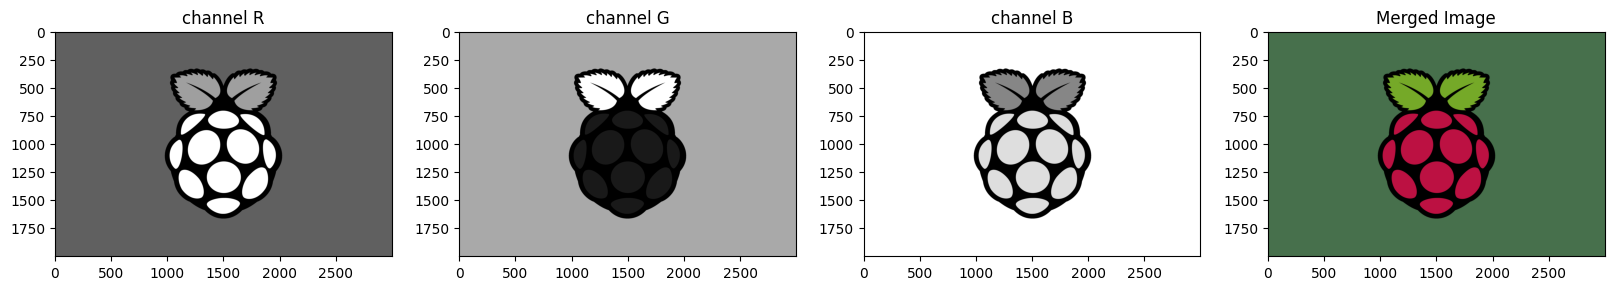

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve
from IPython.display import Image

def download_and_unzip(url, save_path):
    print("Downloading and extracting assets...", end="")

    # Descargar archivo ZIP
    urlretrieve(url, save_path)

    try:
        with ZipFile(save_path) as z:
            # Listar el contenido del archivo ZIP
            print("Contenido del archivo ZIP antes de la extracción:")
            for name in z.namelist():
                print(name)

            # Extraer contenido del archivo ZIP en el directorio actual
            z.extractall(os.getcwd())
        print("Done")
    except Exception as e:
        print("\nInvalid file.", e)

# URL del archivo ZIP en Dropbox
URL = r"https://www.dropbox.com/scl/fi/axa4tdrq3g9crg20rep7v/logos.zip?rlkey=875rejmvptqwvgf19a3lzwnjw&st=x0ay8vaq&dl=1"
asset_zip_path = os.path.join(os.getcwd(), "logos.zip")

# Descargar y extraer el archivo ZIP si no existe
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

# Listar archivos en el directorio actual para verificar la existencia del archivo de imagen
print("Contenido del directorio después de la extracción:")
print(os.listdir(os.getcwd()))

# Verificar la ruta de la imagen
image_path = os.path.join(os.getcwd(), "Raspberry_Pi-Logo.wine.png")
print(f"Ruta de la imagen: {image_path}")
print(f"Archivo existe: {os.path.exists(image_path)}")

# Leer la imagen
img_5_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
if img_5_bgr is None:
    raise ValueError("La imagen no se pudo cargar. Verifica la ruta del archivo y asegúrate de que el archivo existe.")

# Separar los canales de color
b, g, r = cv2.split(img_5_bgr)

# Visualizar los canales y la imagen fusionada
plt.figure(figsize=[20, 5])
plt.subplot(141); plt.imshow(r, cmap="gray"); plt.title("channel R")
plt.subplot(142); plt.imshow(g, cmap="gray"); plt.title("channel G")
plt.subplot(143); plt.imshow(b, cmap="gray"); plt.title("channel B")

imgMerged = cv2.merge([b, g, r])
plt.subplot(144)
plt.imshow(imgMerged[:, :, ::-1])
plt.title("Merged Image")
plt.show()

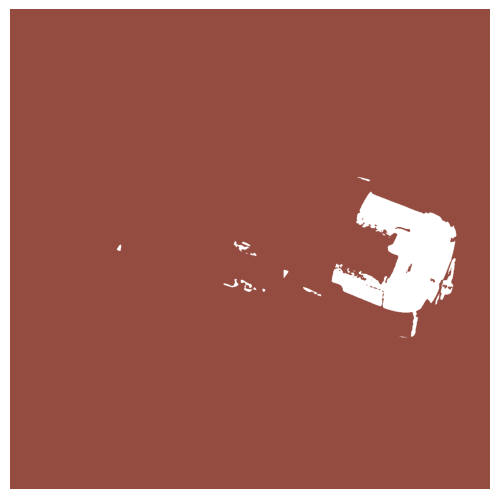

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen en escala de grises y redimensionarla
img_gray = cv2.imread('7.jpg', cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(img_gray, (img_gray.shape[1]*2, img_gray.shape[0]*2))  # Duplicar el tamaño

# Invertir el contraste de la imagen
img_invertida = cv2.bitwise_not(img_gray)

# Aplicar filtro Gaussiano
blurred = cv2.GaussianBlur(img_invertida, (5, 5), 0)

# Aplicar umbral para segmentación básica
_, segmented = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# Crear una imagen de color para el fondo
background_color = (64, 75, 148)  # Color de fondo personalizado
colored_background = np.zeros((img_gray.shape[0], img_gray.shape[1], 3), dtype=np.uint8)
colored_background[:] = background_color

# Crear una imagen en blanco para colorear los segmentos
color_segmentos = np.zeros_like(colored_background)

# Definir el color deseado para los segmentos en formato BGR (blanco)
color = [255, 255, 255]  # Segmentos blancos

# Aplicar el color a los segmentos detectados
color_segmentos[segmented != 0] = color

# Combinar la imagen original con los segmentos coloreados
resultado = cv2.addWeighted(colored_background, 1, color_segmentos, 1, 0)

# Mostrar la imagen resultante sin títulos ni ejes y eliminar el marco blanco
fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
ax.axis('off')  # Desactivar los ejes
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Eliminar el marco blanco
plt.show()

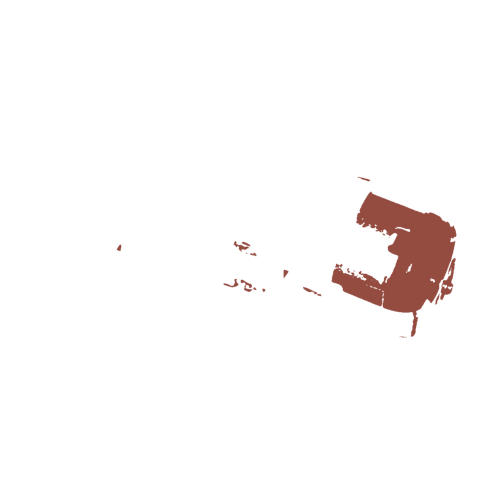

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Leer la imagen en escala de grises y redimensionarla
img_gray = cv2.imread('7.jpg', cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(img_gray, (img_gray.shape[1]*2, img_gray.shape[0]*2))  # Duplicar el tamaño

# Aplicar filtro Gaussiano
blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Aplicar umbral para segmentación básica
_, segmented = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY)

# Crear una imagen de color para el fondo
background_color = (64, 75, 148)  # Color de fondo personalizado
colored_background = np.zeros((img_gray.shape[0], img_gray.shape[1], 3), dtype=np.uint8)
colored_background[:] = background_color

# Crear una imagen en blanco para colorear los segmentos
color_segmentos = np.zeros_like(colored_background)

# Definir el color deseado para los segmentos en formato BGR (blanco)
color = [255, 255, 255]  # Segmentos blancos

# Aplicar el color a los segmentos detectados
color_segmentos[segmented != 0] = color

# Combinar la imagen original con los segmentos coloreados
resultado = cv2.addWeighted(colored_background, 1, color_segmentos, 1, 0)

# Mostrar la imagen resultante sin títulos ni ejes y eliminar el marco blanco
fig, ax = plt.subplots()
ax.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
ax.axis('off')  # Desactivar los ejes
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Eliminar el marco blanco
plt.show()